# Tauron ML playground (production parity)

This notebook mirrors the **current** `ai_engine` training path so you can experiment with **feature engineering**, **targets**, and **estimators** locally, then port stable ideas into `ai_engine/app/services/feature_matrix_builder.py` and `training_pipeline.py`.

**Parity scope**

- Data: `on_chain_metrics` long → wide daily panel (same pivot, ffill, leakage shift, temporal augmentation, variance cap) via `build_training_frame_for_asset`.
- Target: next calendar day's **USD close** from Coin Metrics **PriceUSD** (row dated **t** predicts **p[t+1]**).
- Training: `train_estimator_bundle` — **TimeSeriesSplit** CV then refit on full history (same as workers for sklearn slugs).

**Run**

From the repo root, use the ai_engine interpreter (PostgreSQL reachable with the same env as Docker, e.g. `localhost` and `.env` in `ai_engine/`):

```text
uv run --directory ai_engine python -m jupyter lab ..\train.ipynb
```

Install Jupyter in that env once if needed: `uv pip install jupyterlab ipykernel`.

In [129]:
"""Imports and Python path so ``app.*`` resolves to ``ai_engine/app``."""

from __future__ import annotations

import sys
from pathlib import Path


def resolve_ai_engine_directory(starting_directory: Path) -> Path:
    """Return the directory that contains the ``app`` package for this project."""

    resolved_start = starting_directory.resolve()
    for candidate_directory in [resolved_start, *resolved_start.parents]:
        sibling_ai_engine = candidate_directory / "ai_engine"
        if sibling_ai_engine.is_dir() and (sibling_ai_engine / "app").is_dir():
            return sibling_ai_engine
        if (candidate_directory / "app").is_dir() and (candidate_directory / "pyproject.toml").is_file():
            return candidate_directory
    raise FileNotFoundError(
        "Could not locate ai_engine (no ai_engine/app or app+pyproject.toml upward from "
        f"{resolved_start}). Open or run the notebook from the repo root or from ai_engine."
    )


AI_ENGINE_ROOT = resolve_ai_engine_directory(Path.cwd())
REPO_ROOT = AI_ENGINE_ROOT.parent

if str(AI_ENGINE_ROOT) not in sys.path:
    sys.path.insert(0, str(AI_ENGINE_ROOT))

from dotenv import load_dotenv

load_dotenv(AI_ENGINE_ROOT / ".env")

True

In [130]:
import sys
print(sys.executable)

c:\Users\IT\Desktop\Tauron_CSE491\.venv\Scripts\python.exe


In [131]:
"""Load settings identical to the running AI engine (Postgres URL, schema, column cap)."""

from uuid import UUID

from app.core.config import settings
from app.db.postgres_accessor import PostgresAccessConfig, fetch_active_asset_ids, open_connection
from app.services.feature_matrix_builder import TrainingFrameBuildResult, build_training_frame_for_asset
from app.services.training_pipeline import FittedEstimatorBundle, train_estimator_bundle

DATABASE_URL_PREVIEW = settings.sync_database_url.split("@")[-1] if "@" in settings.sync_database_url else "(local)"
COLUMN_CAP = int(settings.TRAIN_MAX_ONCHAIN_METRIC_COLUMNS)
MODEL_SLUG = settings.TRAIN_DEFAULT_MODEL_TYPE.strip() or "hgb_ocm"
CV_FOLDS = 5

print("schema:", settings.validated_schema_name)
print("column_cap:", COLUMN_CAP)
print("default model slug:", MODEL_SLUG)
print("database tail:", DATABASE_URL_PREVIEW)

schema: tauron
column_cap: 80
default model slug: hgb_ocm
database tail: localhost:5433/tauron


In [132]:
"""Resolve an asset: set ASSET_ID here, or leave None to pick the first active asset."""

ASSET_ID: UUID | None = '3a2ca754-44d9-4fa1-801c-560de9cc7207'

pg = PostgresAccessConfig(
    sync_database_url=settings.sync_database_url,
    schema_name=settings.validated_schema_name,
    ssl_enabled=bool(settings.POSTGRES_SSL),
)

if ASSET_ID is None:
    candidates = fetch_active_asset_ids(pg)
    if not candidates:
        raise RuntimeError("No active assets in the database.")
    ASSET_ID = candidates[0]

print("asset_id:", ASSET_ID)

asset_id: 3a2ca754-44d9-4fa1-801c-560de9cc7207


In [133]:
from app.core.config import settings

settings.POSTGRES_PORT = 5433

In [134]:
"""Build the supervised frame (exact production builder)."""


def load_training_bundle_for_asset(asset_id: UUID, column_cap: int) -> TrainingFrameBuildResult:
    """Return feature matrix + target + closes aligned exactly like worker training."""
    with open_connection(pg) as connection:
        built = build_training_frame_for_asset(
            connection=connection,
            schema_name=settings.validated_schema_name,
            asset_id=asset_id,
            column_cap=column_cap,
        )
    if built is None:
        raise RuntimeError("Insufficient on-chain rows or missing PriceUSD for this asset.")
    return built


bundle = load_training_bundle_for_asset(ASSET_ID, COLUMN_CAP)

X = bundle.feature_frame.astype(float)
y = bundle.target_series.astype(float)
closes = bundle.closes_aligned.astype(float)

print("X:", X.shape, "UTC index tz:", X.index.tz)
print("y:", y.shape)
print("columns (first 25):", list(X.columns[:25]))

C:\Users\IT\Desktop\Tauron_CSE491\ai_engine\app\db\postgres_accessor.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  frame = pd.read_sql_query(


X: (1824, 80) UTC index tz: UTC
y: (1824,)
columns (first 25): ['ocm_CapMrktCurUSD_lag30', 'ocm_CapMrktEstUSD_lag30', 'ocm_CapMrktCurUSD_lag7', 'ocm_CapMrktEstUSD_lag7', 'ocm_CapMrktCurUSD_lag1', 'ocm_CapMrktEstUSD_lag1', 'ocm_CapMrktCurUSD', 'ocm_CapMrktEstUSD', 'ocm_SplyExUSD_lag7', 'ocm_volume_reported_spot_usd_1d_lag7', 'ocm_FlowOutExUSD_lag30', 'ocm_FlowInExUSD_lag30', 'ocm_HashRate_lag30', 'ocm_AssetCompletionTime_lag30', 'ocm_AssetEODCompletionTime_lag30', 'ocm_IssTotUSD_lag30', 'ocm_IssTotUSD_lag7', 'ocm_AdrBalCnt_lag30', 'ocm_SplyCur_lag7', 'ocm_TxTfrCnt_lag7', 'ocm_TxCnt_lag7', 'ocm_AdrActCnt_lag30', 'ocm_SplyExNtv_lag7', 'ocm_SplyExpFut10yr_lag7', 'ocm_PriceUSD_lag30']


C:\Users\IT\Desktop\Tauron_CSE491\ai_engine\app\services\feature_matrix_builder.py:72: RuntimeWarning: Degrees of freedom <= 0 for slice.
  variance_value = float(np.nanvar(series.to_numpy(dtype=float), ddof=0))


### Optional inclusive data cutoff (Walk-forward lab parity)

Set **`INCLUSIVE_DATA_CUTOFF_UTC_DAY`** to a `yyyy-mm-dd` string to drop **all rows after that UTC calendar day** before modelling (same truncation as `maximum_training_feature_calendar_day_utc` in workers). Leave **`None`** to use every aligned row returned by `build_training_frame_for_asset`.

In [135]:
"""Mirror worker truncation when experimenting with withheld future data."""

import pandas as pd

INCLUSIVE_DATA_CUTOFF_UTC_DAY: str | None = "2026-01-01"
TRAINING_INCLUSIVE_CUTOFF_UTC: pd.Timestamp | None = None
X_full_history_for_forward_eval = X.copy()
y_full_history_for_forward_eval = y.copy()
closes_full_history_for_forward_eval = closes.copy()

if INCLUSIVE_DATA_CUTOFF_UTC_DAY:
    from app.jobs.train_single_asset import (
        _exclusive_calendar_cutoff_timestamp_from_literal_or_raise_exclusive,
        _truncate_training_frame_build_result_through_inclusive_calendar_day_exclusive,
    )

    cutoff_ts = _exclusive_calendar_cutoff_timestamp_from_literal_or_raise_exclusive(
        INCLUSIVE_DATA_CUTOFF_UTC_DAY.strip(),
    )
    TRAINING_INCLUSIVE_CUTOFF_UTC = cutoff_ts
    truncated = _truncate_training_frame_build_result_through_inclusive_calendar_day_exclusive(bundle, cutoff_ts)
    if truncated is None:
        raise RuntimeError("No rows fall on or before the cutoff; widen the window or fix ingestion.")
    bundle = truncated
    X = bundle.feature_frame.astype(float)
    y = bundle.target_series.astype(float)
    closes = bundle.closes_aligned.astype(float)
    print("Applied cutoff; new shape:", X.shape)
else:
    print("No cutoff; full aligned history:", X.shape)

Applied cutoff; new shape: (1701, 80)


In [136]:
"""Light inspection of the current feature state (edit this cell as you add columns)."""

summary = X.describe().T[["mean", "std", "min", "max"]]
summary["non_null_frac"] = X.notna().mean()
summary.sort_values("std", ascending=False).head(20)

,mean,std,min,max,non_null_frac
ocm_CapMrktCurUSD,1.074087e+12,6.112688e+11,3.026051e+11,2.487865e+12,1.000000
ocm_CapMrktEstUSD,1.074056e+12,6.112596e+11,3.025924e+11,2.487527e+12,1.000000
ocm_CapMrktCurUSD_lag1,1.073677e+12,6.112147e+11,3.026051e+11,2.487865e+12,0.999412
ocm_CapMrktEstUSD_lag1,1.073646e+12,6.112054e+11,3.025924e+11,2.487527e+12,0.999412
ocm_CapMrktCurUSD_lag7,1.071281e+12,6.109663e+11,3.026051e+11,2.487865e+12,0.995885
ocm_CapMrktEstUSD_lag7,1.071250e+12,6.109570e+11,3.025924e+11,2.487527e+12,0.995885
ocm_CapMrktCurUSD_lag30,1.061507e+12,6.093876e+11,3.026051e+11,2.487865e+12,0.982363
ocm_CapMrktEstUSD_lag30,1.061476e+12,6.093780e+11,3.025924e+11,2.487527e+12,0.982363
ocm_SplyExUSD_lag30,1.595855e+11,8.571599e+10,4.571000e+10,3.476864e+11,0.982363
ocm_SplyExUSD_lag7,1.606745e+11,8.563946e+10,4.571000e+10,3.476864e+11,0.995885


### Train (same as `train_estimator_bundle` in workers)

Override **`MODEL_SLUG`** in an earlier cell or below. Supported sklearn slugs: `hgb_ocm`, `ridge_ocm`, `rf_ocm`, `et_ocm`, `lgbm_ocm` (requires LightGBM). Optional **`ESTIMATOR_OVERRIDES`** maps to the underlying estimator’s `set_params` (same as the Backtests hyper form; exclude `time_series_cv_folds` from that dict and use **`CV_FOLDS`** instead).

In [137]:
"""Fit with TimeSeriesSplit CV then full-data refit (production sklearn path)."""

TRAIN_MODEL_SLUG = MODEL_SLUG
TRAIN_CV_FOLDS = CV_FOLDS
ESTIMATOR_OVERRIDES: dict | None = None

fitted: FittedEstimatorBundle = train_estimator_bundle(
    X,
    y,
    model_type_slug=TRAIN_MODEL_SLUG,
    n_cv_splits=TRAIN_CV_FOLDS,
    estimator_param_overrides_exclusive=ESTIMATOR_OVERRIDES,
)

print("model_type_slug:", fitted.model_type_slug)
print("training rows:", fitted.training_observation_rows)
print("cv MAE by fold:", [round(v, 6) for v in (fitted.cv_fold_mae_values or [])])
print("cv mean MAE:", fitted.cv_mean_mae, "std:", fitted.cv_std_mae)
print("final fold MAE (stored as validation_mae in registry):", fitted.validation_absolute_error_mean)
print("residual sigma (CI calibration):", fitted.residual_standard_error)

c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-package

model_type_slug: hgb_ocm
training rows: 1701
cv MAE by fold: [0.037244, 0.035687, 0.02639, 0.021725, 0.016571]
cv mean MAE: 0.027523287060540295 std: 0.0079499490440276
final fold MAE (stored as validation_mae in registry): 0.016570549516672948
residual sigma (CI calibration): 0.02240528035200142


### Actual vs predicted (and feature list)

The next cell prints **`fitted.feature_column_order`**, then plots **cross-validation out-of-fold** predictions (**TimeSeriesSplit** validation rows only). That answers "how would past folds have looked," not "what happens after I freeze training on a cutoff." Rows that never appear in a validation fold stay off those charts.

**If you set `INCLUSIVE_DATA_CUTOFF_UTC_DAY`:** run the **Forward evaluation after training cutoff** cell below. It keeps the **full** aligned history, fits on the truncated `X`/`y` above, then applies the **final refit** pipeline to feature days on or after a start you choose—**actual vs predicted** next-day **USD close** only on that post-cutoff window.

The third subplot in the OOF cell is an optional **120-day compounded level** geometry using implied log steps from OOF **USD** next-close forecasts; it is *not* a trained 120-day target.

80 feature columns (model input order):
  1. ocm_CapMrktCurUSD_lag30
  2. ocm_CapMrktEstUSD_lag30
  3. ocm_CapMrktCurUSD_lag7
  4. ocm_CapMrktEstUSD_lag7
  5. ocm_CapMrktCurUSD_lag1
  6. ocm_CapMrktEstUSD_lag1
  7. ocm_CapMrktCurUSD
  8. ocm_CapMrktEstUSD
  9. ocm_SplyExUSD_lag7
 10. ocm_volume_reported_spot_usd_1d_lag7
 11. ocm_FlowOutExUSD_lag30
 12. ocm_FlowInExUSD_lag30
 13. ocm_HashRate_lag30
 14. ocm_AssetCompletionTime_lag30
 15. ocm_AssetEODCompletionTime_lag30
 16. ocm_IssTotUSD_lag30
 17. ocm_IssTotUSD_lag7
 18. ocm_AdrBalCnt_lag30
 19. ocm_SplyCur_lag7
 20. ocm_TxTfrCnt_lag7
 21. ocm_TxCnt_lag7
 22. ocm_AdrActCnt_lag30
 23. ocm_SplyExNtv_lag7
 24. ocm_SplyExpFut10yr_lag7
 25. ocm_PriceUSD_lag30
 26. ocm_PriceUSD_lag7
 27. ocm_FlowInExNtv_lag30
 28. ocm_FlowOutExNtv_lag30
 29. ocm_IssTotNtv_lag30
 30. ocm_ROI1yr_lag30
 31. ocm_ROI1yr_lag7
 32. ocm_FeeTotNtv_lag30
 33. ocm_ROI30d_lag30
 34. ocm_ROI30d_lag7
 35. ocm_BlkCnt_lag30
 36. ocm_CapMVRVCur_lag30
 37. ocm_PriceBTC_lag7


c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-package

TimeSeriesSplit evaluation rows (plotted): 1415
Third panel: H= 120 calendar days (compounded midpoint; implied log-step sigma= 0.022405 )


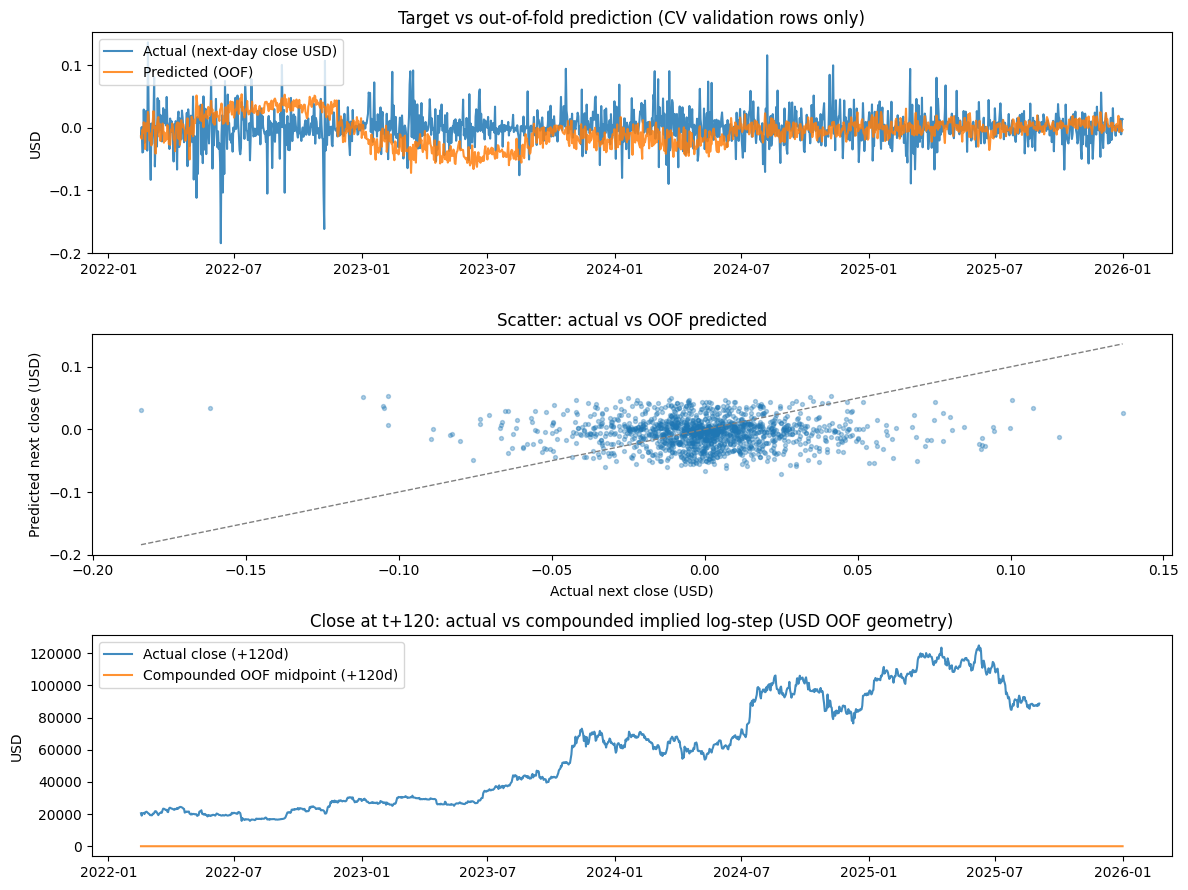

Mean absolute error on next close USD (OOF rows): 0.027523


In [138]:
"""Feature columns used by the fitted pipeline and OOF-only plots (no full-history leakage)."""

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.core.config import settings

import app.services.training_pipeline as training_pipeline_module

importlib.reload(training_pipeline_module)

time_series_out_of_fold_predicted_targets = (
    training_pipeline_module.time_series_out_of_fold_predicted_targets
)

FEATURE_COLUMNS_USED = list(fitted.feature_column_order)
print(len(FEATURE_COLUMNS_USED), "feature columns (model input order):")
for column_index, column_name in enumerate(FEATURE_COLUMNS_USED, start=1):
    print(f"{column_index:3d}. {column_name}")

oof_predicted = time_series_out_of_fold_predicted_targets(
    X,
    y,
    model_type_slug=TRAIN_MODEL_SLUG,
    n_splits=TRAIN_CV_FOLDS,
    estimator_param_overrides_exclusive=ESTIMATOR_OVERRIDES,
)
evaluation_mask = oof_predicted.notna()
oof_row_count = int(evaluation_mask.sum())
if oof_row_count == 0:
    raise RuntimeError("No out-of-fold predictions; check TRAIN_CV_FOLDS and row count.")
print("TimeSeriesSplit evaluation rows (plotted):", oof_row_count)

aligned_index = oof_predicted.index[evaluation_mask]
y_actual = y.loc[aligned_index]
y_predicted_oof = oof_predicted.loc[aligned_index]

diagnostics_frame = pd.DataFrame(
    {
        "actual_next_close_usd": y_actual,
        "predicted_next_close_usd": y_predicted_oof,
    }
)
diagnostics_frame["prediction_error_usd"] = (
    diagnostics_frame["actual_next_close_usd"] - diagnostics_frame["predicted_next_close_usd"]
)

closes_aligned = closes.loc[aligned_index]
implied_log_step_oof = np.log(
    np.maximum(diagnostics_frame["predicted_next_close_usd"].astype(float), 1e-12)
    / np.maximum(closes_aligned.astype(float), 1e-12)
)
LEVEL_PLOT_HORIZON_DAYS = 120
horizon_step_count = max(1, int(LEVEL_PLOT_HORIZON_DAYS))
sigma_residual_log = max(
    float(fitted.residual_standard_error),
    float(settings.TRAIN_FORECAST_LOG_SIGMA_FLOOR),
)
horizon_multiplier = float(horizon_step_count)
ito_bias_log = 0.5 * (sigma_residual_log ** 2) * horizon_multiplier
cumulative_log_at_horizon = (
    horizon_multiplier * implied_log_step_oof.astype(float) + ito_bias_log
)
predicted_horizon_close = closes_aligned * np.exp(cumulative_log_at_horizon)
actual_horizon_close = closes_aligned.shift(-horizon_step_count)
print(
    "Third panel: H=",
    horizon_step_count,
    "calendar days (compounded midpoint; implied log-step sigma=",
    round(sigma_residual_log, 6),
    ")",
)
price_frame = pd.DataFrame(
    {
        "anchor_close": closes_aligned,
        "actual_next_day_close": diagnostics_frame["actual_next_close_usd"],
        "predicted_next_day_close": diagnostics_frame["predicted_next_close_usd"],
        "actual_horizon_close": actual_horizon_close,
        "predicted_horizon_close": predicted_horizon_close,
    }
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[2].sharex(axes[0])

axes[0].plot(
    diagnostics_frame.index,
    diagnostics_frame["actual_next_close_usd"],
    label="Actual (next-day close USD)",
    alpha=0.85,
)
axes[0].plot(
    diagnostics_frame.index,
    diagnostics_frame["predicted_next_close_usd"],
    label="Predicted (OOF)",
    alpha=0.85,
)
axes[0].set_ylabel("USD")
axes[0].legend(loc="upper left")
axes[0].set_title("Target vs out-of-fold prediction (CV validation rows only)")

min_edge = float(
    np.nanmin(
        [
            diagnostics_frame["actual_next_close_usd"].min(),
            diagnostics_frame["predicted_next_close_usd"].min(),
        ]
    )
)
max_edge = float(
    np.nanmax(
        [
            diagnostics_frame["actual_next_close_usd"].max(),
            diagnostics_frame["predicted_next_close_usd"].max(),
        ]
    )
)
axes[1].scatter(
    diagnostics_frame["actual_next_close_usd"],
    diagnostics_frame["predicted_next_close_usd"],
    s=8,
    alpha=0.35,
)
axes[1].plot([min_edge, max_edge], [min_edge, max_edge], color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Actual next close (USD)")
axes[1].set_ylabel("Predicted next close (USD)")
axes[1].set_title("Scatter: actual vs OOF predicted")

axes[2].plot(
    price_frame.index,
    price_frame["actual_horizon_close"],
    label=f"Actual close (+{horizon_step_count}d)",
    alpha=0.85,
)
axes[2].plot(
    price_frame.index,
    price_frame["predicted_horizon_close"],
    label=f"Compounded OOF midpoint (+{horizon_step_count}d)",
    alpha=0.85,
)
axes[2].set_ylabel("USD")
axes[2].legend(loc="upper left")
axes[2].set_title(
    f"Close at t+{horizon_step_count}: actual vs compounded implied log-step (USD OOF geometry)",
)

plt.tight_layout()
plt.show()

mean_absolute_error_usd = float(np.mean(np.abs(diagnostics_frame["prediction_error_usd"])))
print("Mean absolute error on next close USD (OOF rows):", round(mean_absolute_error_usd, 6))

### Forward evaluation after training cutoff

This uses **`X_full_history_for_forward_eval`** / **`y_*`** / **`closes_*`** captured **before** optional truncation, while **`fitted`** is the model trained only on the truncated `X`/`y`.

- Leave **`FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE`** as **`None`** to start on the **first UTC calendar day strictly after** **`TRAINING_INCLUSIVE_CUTOFF_UTC`** (walk-forward after an inclusive lab cutoff).
- Set it to **`"2026-01-01"`** (or any `yyyy-mm-dd`) to plot **every feature day on or after** that midnight UTC, including overlap with the last training day if those coincide (then that day is not fully out-of-sample for the final refit).

Forward feature rows: 124
Forward window (UTC): 2026-01-01 00:00:00+00:00 -> 2026-05-04 00:00:00+00:00
Mean |error| on next close USD (forward): 0.021933


c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


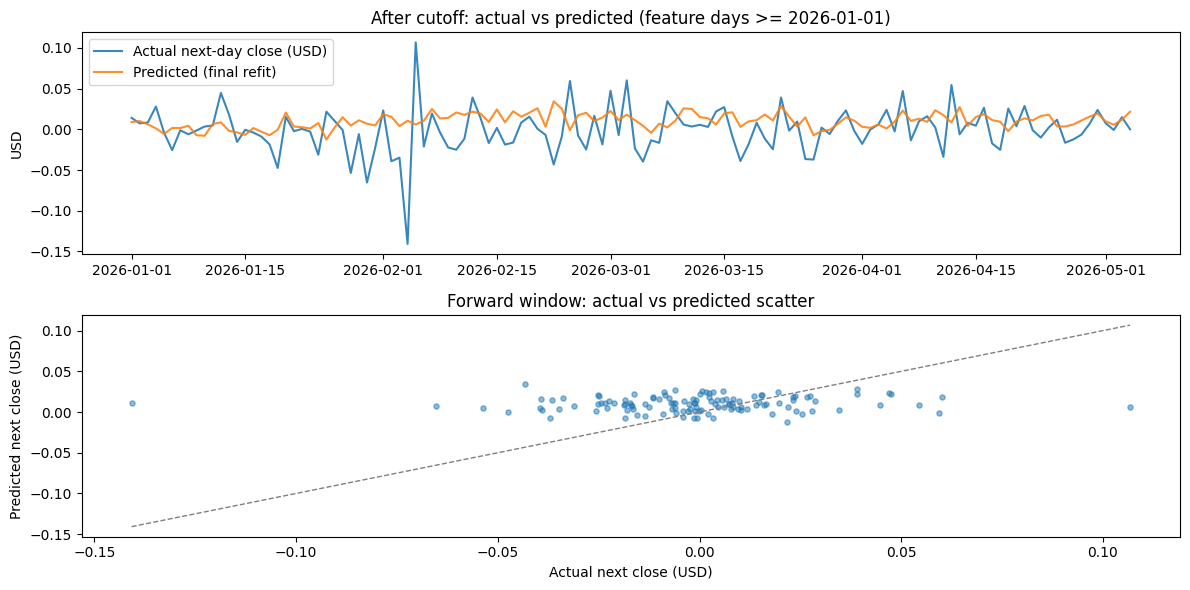

In [139]:
"""Actual vs predicted on the post-cutoff calendar window using the final refit pipeline."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE: str | None = "2026-01-01"

if FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE is None:
    if TRAINING_INCLUSIVE_CUTOFF_UTC is None:
        raise RuntimeError(
            "Set FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE when no INCLUSIVE_DATA_CUTOFF_UTC_DAY was applied."
        )
    forward_feature_day_lower_bound_inclusive = TRAINING_INCLUSIVE_CUTOFF_UTC + pd.Timedelta(days=1)
else:
    forward_feature_day_lower_bound_inclusive = pd.Timestamp(
        FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE.strip(),
        tz="UTC",
    )

forward_row_mask = X_full_history_for_forward_eval.index >= forward_feature_day_lower_bound_inclusive
X_forward_aligned = X_full_history_for_forward_eval.loc[forward_row_mask].reindex(
    columns=fitted.feature_column_order,
)
if len(X_forward_aligned) == 0:
    raise RuntimeError(
        "No rows on or after the forward start; extend ingestion or choose an earlier FORWARD_EVAL_MIN_FEATURE_UTC_DAY_INCLUSIVE."
    )

y_forward_actual = y_full_history_for_forward_eval.loc[X_forward_aligned.index].astype(float)

forward_predicted_next_close_usd = pd.Series(
    fitted.pipeline.predict(X_forward_aligned).astype(float),
    index=X_forward_aligned.index,
    name="predicted_next_close_usd",
)

forward_evaluation_frame = pd.DataFrame(
    {
        "actual_next_close_usd": y_forward_actual,
        "predicted_next_close_usd": forward_predicted_next_close_usd,
    },
)
forward_evaluation_frame["prediction_error_usd"] = (
    forward_evaluation_frame["actual_next_close_usd"] - forward_evaluation_frame["predicted_next_close_usd"]
)

mean_absolute_error_usd_forward = float(
    np.mean(np.abs(forward_evaluation_frame["prediction_error_usd"]))
)
print("Forward feature rows:", len(forward_evaluation_frame))
print("Forward window (UTC):", forward_evaluation_frame.index.min(), "->", forward_evaluation_frame.index.max())
print("Mean |error| on next close USD (forward):", round(mean_absolute_error_usd_forward, 6))

fig_forward, forward_axes = plt.subplots(2, 1, figsize=(12, 6))
forward_axes[0].plot(
    forward_evaluation_frame.index,
    forward_evaluation_frame["actual_next_close_usd"],
    label="Actual next-day close (USD)",
    alpha=0.88,
)
forward_axes[0].plot(
    forward_evaluation_frame.index,
    forward_evaluation_frame["predicted_next_close_usd"],
    label="Predicted (final refit)",
    alpha=0.88,
)
forward_axes[0].set_ylabel("USD")
forward_axes[0].legend(loc="upper left")
forward_axes[0].set_title(
    f"After cutoff: actual vs predicted (feature days >= {forward_feature_day_lower_bound_inclusive.date()})"
)

scatter_min_edge = float(
    min(
        forward_evaluation_frame["actual_next_close_usd"].min(),
        forward_evaluation_frame["predicted_next_close_usd"].min(),
    )
)
scatter_max_edge = float(
    max(
        forward_evaluation_frame["actual_next_close_usd"].max(),
        forward_evaluation_frame["predicted_next_close_usd"].max(),
    )
)
forward_axes[1].scatter(
    forward_evaluation_frame["actual_next_close_usd"],
    forward_evaluation_frame["predicted_next_close_usd"],
    s=14,
    alpha=0.5,
)
forward_axes[1].plot(
    [scatter_min_edge, scatter_max_edge],
    [scatter_min_edge, scatter_max_edge],
    color="gray",
    linestyle="--",
    linewidth=1,
)
forward_axes[1].set_xlabel("Actual next close (USD)")
forward_axes[1].set_ylabel("Predicted next close (USD)")
forward_axes[1].set_title("Forward window: actual vs predicted scatter")

plt.tight_layout()

In [140]:
"""One-step prediction on the last training row: model predicts next-day USD close."""

import numpy as np

last_features = X.iloc[-1:].copy()
predicted_next_close_usd_terminal = float(fitted.pipeline.predict(last_features)[0])
last_close = float(closes.loc[X.index[-1]])
derived_log_return = float(np.log(predicted_next_close_usd_terminal / max(last_close, 1e-12)))

print("anchor day (index):", X.index[-1])
print("predicted next close (USD):", predicted_next_close_usd_terminal)
print("anchor close (PriceUSD same-day):", last_close)
print("implied log return vs anchor (derived):", derived_log_return)

anchor day (index): 2026-01-01 00:00:00+00:00
predicted next close (USD): 0.008958158759975228
anchor close (PriceUSD same-day): 88684.2178474576
implied log return vs anchor (derived): -16.108027793805967


c:\Users\IT\Desktop\Tauron_CSE491\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ocm_ReferenceRate_lag7' 'ocm_ReferenceRateETH_lag7'
 'ocm_ReferenceRateEUR_lag7' 'ocm_ReferenceRateUSD_lag7'
 'ocm_ReferenceRate_lag30' 'ocm_ReferenceRateETH_lag30'
 'ocm_ReferenceRateEUR_lag30' 'ocm_ReferenceRateUSD_lag30']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


### Scratch: prototype features before touching `feature_matrix_builder.py`

Ideas belong in **`X_augmented`**: concat or join new columns onto `X`, keep the **`DatetimeIndex`** aligned, then temporarily pass **`X_augmented`** into **`train_estimator_bundle`**. Stable wins get merged into **`augment_with_temporal_features`** or a new helper in **`ai_engine/app/services/feature_matrix_builder.py`**, ranked by **`capped_metric_columns_from_wide`** (or whichever selection rule you codify).

**LSTM playground** mirrors a different pipeline (`train_lstm_for_asset`); add a dedicated section once sklearn experiments stabilise—otherwise keep this notebook sklearn-first for parity with HistGradientBoosting-style workers.

In [141]:
"""Template for experimental columns derived from ``X``."""

import pandas as pd


def augment_features_placeholder(feature_frame: pd.DataFrame) -> pd.DataFrame:
    """Return a new frame identical to ``feature_frame`` until you add prototypes."""
    return feature_frame.astype(float)


X_augmented = augment_features_placeholder(X.copy())
assert X_augmented.index.equals(X.index), "Index must remain the daily UTC stem."
print("baseline columns:", X.shape[1], "after placeholder:", X_augmented.shape[1])

baseline columns: 80 after placeholder: 80


### Optional artifact export

The cell below saves the same **`bundle_to_joblib_dict`** envelope the worker serialises; useful diffing artefacts against production training without hitting the backend registry.

In [142]:
"""Persist playground bundle beside the repo for diffing."""

import joblib

from app.services.training_pipeline import bundle_to_joblib_dict

ARTIFACT_ENABLED = False
ARTIFACT_PATH = REPO_ROOT / "_playground_estimator_bundle.joblib"

if ARTIFACT_ENABLED:
    joblib.dump(bundle_to_joblib_dict(fitted), ARTIFACT_PATH)
    print("Wrote:", ARTIFACT_PATH)
else:
    print("Set ARTIFACT_ENABLED = True after a successful fit to serialize.")

Set ARTIFACT_ENABLED = True after a successful fit to serialize.
